# Spaceship Titanic - CatBoost Model (Python)
This notebook replicates the R pipeline using CatBoost.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [2]:
# Load Data
data = pd.read_csv("../data/preprocessed_data.csv")
test = pd.read_csv("../data/preprocessed_test.csv")

data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,DeckF,DeckG,DeckT,DeckG_midCabin,DeckE_midCabin,DeckF_midCabin,CryoSleep_spending_conflict,NoSpending_notCryo,total_spending_family,avg_spending_family
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109,9,25,...,1,0,0,0,0,0,0,0,736,736.0
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43,3576,0,...,0,0,0,0,0,0,0,0,15559,7779.5
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0,1283,371,...,0,0,0,0,0,0,0,0,15559,7779.5
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303,70,151,...,1,0,0,0,0,0,0,0,1091,1091.0


In [3]:
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'Group', 'Number', 'total_spending', 'Deck',
       'Cabin_num', 'Side', 'GroupNumberCount', 'LastName',
       'FamilyMembersCount', 'FamilyMembersCabinCount', 'NameFlag',
       'CabinMidFlag', 'HomePlanetEarth', 'HomePlanetEuropa', 'HomePlanetMars',
       'HomePlanetOther', 'Destination55 Cancri e', 'DestinationOther',
       'DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e', 'Group1',
       'Group2', 'Group3', 'Group4', 'Group5', 'Group6', 'Group7', 'Group8',
       'DeckA', 'DeckB', 'DeckC', 'DeckD', 'DeckE', 'DeckF', 'DeckG', 'DeckT',
       'DeckG_midCabin', 'DeckE_midCabin', 'DeckF_midCabin',
       'CryoSleep_spending_conflict', 'NoSpending_notCryo',
       'total_spending_family', 'avg_spending_family'],
      dtype='str')

In [4]:
# Selected Columns
selected_columns = [
    "CryoSleep", "Age", "VIP", "RoomService", "FoodCourt",
    "ShoppingMall", "Spa", "VRDeck", "Cabin_num", "Side",
    "CabinMidFlag", "HomePlanetEarth", "HomePlanetEuropa",
    "HomePlanetMars", "Destination55 Cancri e",
    "DestinationPSO J318.5-22", "DestinationTRAPPIST-1e",
    "Group1", "Group2", "Group3", "Group4", "Group5",
    "Group6", "Group7", "DeckA", "DeckB", "DeckC",
    "DeckD", "DeckE", "DeckF", "DeckG",
    "FamilyMembersCabinCount", "avg_spending_family"
]

target_column = "Transported" 

In [5]:
# Prepare Data
X = data[selected_columns]
y = data[target_column]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [6]:
# Parameter grid
param_grid = {
    'iterations': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128]
}

# Base CatBoost model
cat = CatBoostClassifier(loss_function='Logloss', eval_metric='Accuracy', verbose=0)

In [7]:
grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,   # 5-fold cross-validation
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'border_count': 128, 'depth': 4, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
Best cross-validation accuracy: 0.8141384015753822


In [8]:
best_params = grid_search.best_params_

best_model = CatBoostClassifier(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    border_count=best_params['border_count'],
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=100
)

best_model.fit(X_train, y_train)

0:	learn: 0.7428097	total: 2.41ms	remaining: 1.2s
100:	learn: 0.8151604	total: 255ms	remaining: 1s
200:	learn: 0.8380417	total: 504ms	remaining: 750ms
300:	learn: 0.8546593	total: 762ms	remaining: 504ms
400:	learn: 0.8632238	total: 1.02s	remaining: 252ms
499:	learn: 0.8740892	total: 1.31s	remaining: 0us


CatBoostClassifier(border_count=128, depth=4, eval_metric='Accuracy', iterations=500, l2_leaf_reg=5, learning_rate=0.1, loss_function='Logloss', verbose=100)

In [9]:
# Predictions
preds = best_model.predict(X_holdout)

In [10]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_holdout, preds))

print("\nClassification Report:")
print(classification_report(y_holdout, preds))

Confusion Matrix:
[[350  82]
 [ 74 364]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       432
           1       0.82      0.83      0.82       438

    accuracy                           0.82       870
   macro avg       0.82      0.82      0.82       870
weighted avg       0.82      0.82      0.82       870



In [11]:
# Feature Importance
importances = best_model.get_feature_importance()
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp

,Feature,Importance
6,Spa,11.612780
7,VRDeck,11.151128
0,CryoSleep,9.976374
8,Cabin_num,9.206994
3,RoomService,8.115624
4,FoodCourt,6.602733
1,Age,6.533157
32,avg_spending_family,4.734857
11,HomePlanetEarth,4.672353
9,Side,4.033861


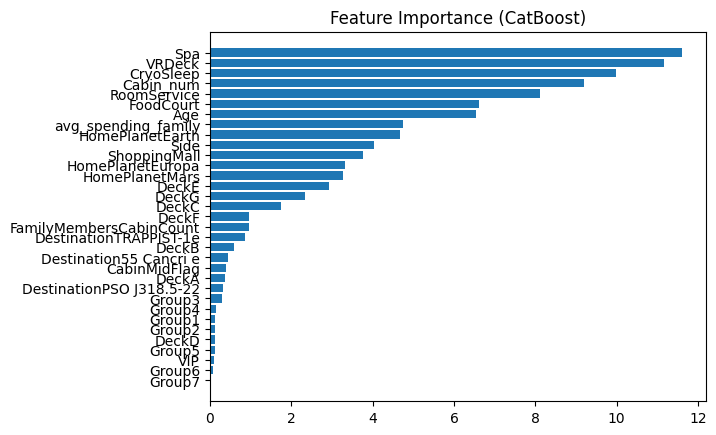

In [12]:
# Plot Feature Importance
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (CatBoost)")
plt.show()

In [13]:
# Analyze Errors
holdout_df = X_holdout.copy()
holdout_df["Actual"] = y_holdout.values
holdout_df["Pred"] = preds

false_positive = holdout_df[
    (holdout_df["Pred"] == 1) & (holdout_df["Actual"] == 0)
]

false_negative = holdout_df[
    (holdout_df["Pred"] == 0) & (holdout_df["Actual"] == 1)
]

false_positive.describe(), false_negative.describe()

(       CryoSleep        Age        VIP  RoomService    FoodCourt  \
 count  82.000000  82.000000  82.000000    82.000000    82.000000   
 mean    0.560976  28.443637   0.012195    12.756098   312.817073   
 std     0.499322  15.585927   0.110432    56.209828  1173.687164   
 min     0.000000   0.000000   0.000000     0.000000     0.000000   
 25%     0.000000  19.000000   0.000000     0.000000     0.000000   
 50%     1.000000  25.000000   0.000000     0.000000     0.000000   
 75%     1.000000  38.750000   0.000000     0.000000     0.000000   
 max     1.000000  65.000000   1.000000   368.000000  9532.000000   
 
        ShoppingMall          Spa       VRDeck    Cabin_num       Side  ...  \
 count     82.000000    82.000000    82.000000    82.000000  82.000000  ...   
 mean     185.182927    57.926829    58.134146   633.646341   0.487805  ...   
 std      467.831222   295.550743   232.011641   512.981779   0.502927  ...   
 min        0.000000     0.000000     0.000000    14.000000  

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CryoSleep'}>],
       [<Axes: title={'center': 'avg_spending_family'}>, <Axes: >]],
      dtype=object)

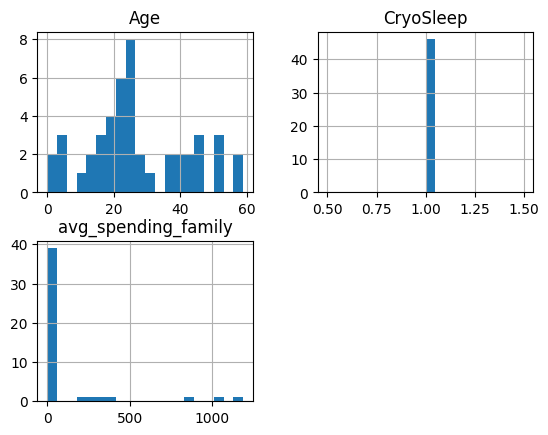

In [14]:
false_positive_with_cryo = false_positive[false_positive["CryoSleep"] == 1]
false_positive_with_cryo[["Age", "CryoSleep", "avg_spending_family"]].hist(bins=20)

In [15]:
false_positive_with_cryo.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Cabin_num', 'Side', 'CabinMidFlag', 'HomePlanetEarth',
       'HomePlanetEuropa', 'HomePlanetMars', 'Destination55 Cancri e',
       'DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e', 'Group1',
       'Group2', 'Group3', 'Group4', 'Group5', 'Group6', 'Group7', 'DeckA',
       'DeckB', 'DeckC', 'DeckD', 'DeckE', 'DeckF', 'DeckG',
       'FamilyMembersCabinCount', 'avg_spending_family', 'Actual', 'Pred'],
      dtype='str')

In [16]:
columns_to_check = ['Destination55 Cancri e','DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e']

# Count 1s in each column
count_ones = false_positive_with_cryo[columns_to_check].apply(lambda x: (x == 1).sum())

In [17]:
count_ones

Destination55 Cancri e       5
DestinationPSO J318.5-22    12
DestinationTRAPPIST-1e      28
dtype: int64

In [18]:
false_positive_with_cryo.count()

CryoSleep                   46
Age                         46
VIP                         46
RoomService                 46
FoodCourt                   46
ShoppingMall                46
Spa                         46
VRDeck                      46
Cabin_num                   46
Side                        46
CabinMidFlag                46
HomePlanetEarth             46
HomePlanetEuropa            46
HomePlanetMars              46
Destination55 Cancri e      46
DestinationPSO J318.5-22    46
DestinationTRAPPIST-1e      46
Group1                      46
Group2                      46
Group3                      46
Group4                      46
Group5                      46
Group6                      46
Group7                      46
DeckA                       46
DeckB                       46
DeckC                       46
DeckD                       46
DeckE                       46
DeckF                       46
DeckG                       46
FamilyMembersCabinCount     46
avg_spen

In [19]:
count = data[(data['CryoSleep'] == 1) & (data['DestinationTRAPPIST-1e'] == 1)].shape[0]
count

1926

<Axes: >

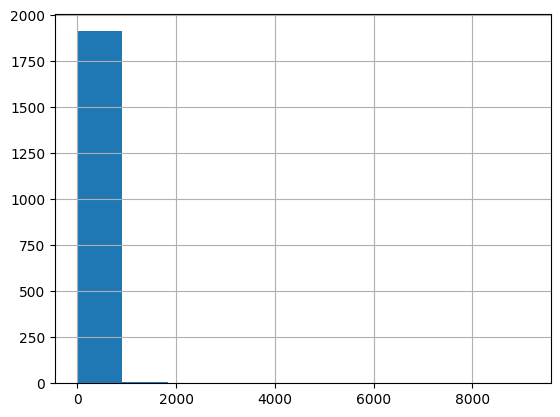

In [20]:
unlogic = data[(data['CryoSleep'] == 1) & (data['DestinationTRAPPIST-1e'] == 1)]["total_spending"]
unlogic.hist()

In [21]:
data['CryoSleep_spending_conflict'].sum()

np.int64(31)

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# selected_columns = [
#     "CryoSleep", "Age", "VIP", "RoomService", "FoodCourt",
#     "ShoppingMall", "Spa", "VRDeck", "Cabin_num", "Side",
#     "CabinMidFlag", "HomePlanetEarth", "HomePlanetEuropa",
#     "HomePlanetMars", "Destination55 Cancri e",
#     "DestinationPSO J318.5-22", "DestinationTRAPPIST-1e",
#     "Group1", "Group2", "Group3", "Group4", "Group5",
#     "Group6", "Group7", "DeckA", "DeckB", "DeckC",
#     "DeckD", "DeckE", "DeckF", "DeckG",
#     "FamilyMembersCabinCount"# , "total_spending"
# ]

data_selected = data[selected_columns]

# Select numeric features
numeric_features = data_selected.select_dtypes(include=['float64', 'int64'])

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_features.values, i) 
                   for i in range(numeric_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

                     feature         VIF
17                    Group1  207.695708
29                     DeckF   93.405898
30                     DeckG   88.757430
18                    Group2   47.825508
16    DestinationTRAPPIST-1e   32.190575
28                     DeckE   29.106554
25                     DeckB   25.141548
26                     DeckC   24.333562
11           HomePlanetEarth   24.209340
19                    Group3   20.001083
27                     DeckD   15.799942
12          HomePlanetEuropa   15.614228
14    Destination55 Cancri e   10.627356
13            HomePlanetMars    9.976232
24                     DeckA    9.008438
20                    Group4    8.562440
1                        Age    5.723783
21                    Group5    5.306496
15  DestinationPSO J318.5-22    5.291138
32       avg_spending_family    5.143945
31   FamilyMembersCabinCount    4.882823
8                  Cabin_num    3.870153
22                    Group6    3.553088
0               

# Submission

In [23]:
test_selected = test[selected_columns]


In [24]:
test_preds = best_model.predict(test_selected)
test_preds = ["True" if pred == 1 else "False" for pred in test_preds]

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": test_preds
})

In [25]:
submission.to_csv("../output/catboost/submission.csv", index=False)